In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.covariance import MinCovDet
from scipy.stats import f as f_dist, norm
import time

np.random.seed(0)
RNG = np.random.default_rng(0)

plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.float_format', lambda x: f'{x:.6g}')

In [28]:
def load_pivot(path):

    df = pd.read_csv(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True)
    piv = df.pivot(index='timestamp', columns='asset_id', values='mid_return').dropna()
    return piv.sort_index()

returns_mon = load_pivot("ticks_mon.csv")
returns_tue = load_pivot("ticks_tue.csv")
print('Monday  :', returns_mon.shape)
print('Tuesday :', returns_tue.shape)
assert (returns_mon.columns == returns_tue.columns).all(), ''

pca_mon = PCA().fit(returns_mon.values)
eigvals_all = pca_mon.explained_variance_
evr = pca_mon.explained_variance_ratio_
print('\nEigenvalues          :', np.round(eigvals_all, 7))
print('Explained var. ratio :', np.round(evr, 4))
print('Cumulative            :', np.round(np.cumsum(evr), 4))

Monday  : (28245, 12)
Tuesday : (28245, 12)

Eigenvalues          : [6.1e-06 3.0e-06 1.1e-06 1.0e-07 1.0e-07 1.0e-07 1.0e-07 1.0e-07 1.0e-07
 1.0e-07 1.0e-07 1.0e-07]
Explained var. ratio : [0.5552 0.2738 0.0972 0.0085 0.0084 0.0083 0.0082 0.0082 0.0081 0.0081
 0.008  0.008 ]
Cumulative            : [0.5552 0.829  0.9262 0.9346 0.943  0.9514 0.9596 0.9678 0.9759 0.984
 0.992  1.    ]


Component-count verdicts: {'kaiser': 3, 'broken_stick': 3, 'parallel_analysis': 3}

Adopted K = 3 (unanimous across Kaiser, broken-stick and parallel analysis; the elbow in the scree plot below is also at 3).


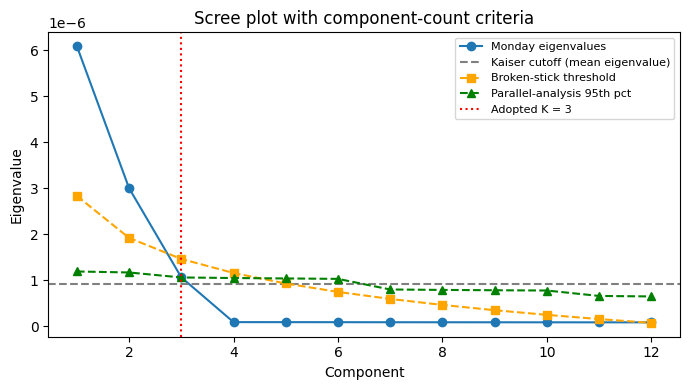

In [29]:
mean_eig = eigvals_all.mean()
kaiser_k = int(np.sum(eigvals_all > mean_eig))

p = len(eigvals_all)
broken_stick_thr = np.array([mean_eig * sum(1/i for i in range(j, p + 1)) for j in range(1, p + 1)])
broken_stick_k = int(np.sum(eigvals_all > broken_stick_thr))

n_resamples = 500
X = returns_mon.values.copy()
resampled_eigs = np.zeros((n_resamples, p))
for i in range(n_resamples):
    Xs = X.copy()
    for c in range(p):
        RNG.shuffle(Xs[:, c])
    resampled_eigs[i] = PCA().fit(Xs).explained_variance_
perc95 = np.percentile(resampled_eigs, 95, axis=0)
parallel_k = int(np.sum(eigvals_all > perc95))

verdicts = {'kaiser': kaiser_k, 'broken_stick': broken_stick_k, 'parallel_analysis': parallel_k}
print('Component-count verdicts:', verdicts)

K = 3
print(f'\nAdopted K = {K} (unanimous across Kaiser, broken-stick and parallel analysis;'
      f' the elbow in the scree plot below is also at 3).')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, p + 1), eigvals_all, 'o-', label='Monday eigenvalues')
ax.axhline(mean_eig, color='grey', ls='--', label='Kaiser cutoff (mean eigenvalue)')
ax.plot(range(1, p + 1), broken_stick_thr, 's--', color='orange', label='Broken-stick threshold')
ax.plot(range(1, p + 1), perc95, '^--', color='green', label='Parallel-analysis 95th pct')
ax.axvline(K, color='red', ls=':', label=f'Adopted K = {K}')
ax.set_xlabel('Component'); ax.set_ylabel('Eigenvalue'); ax.set_title('Scree plot with component-count criteria')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

Q  -- mean in window: 6.0541e-06   mean outside: 8.1044e-07   ratio: 7.5x
T2 -- mean in window: 2.9801   mean outside: 2.9961   ratio: 0.99x


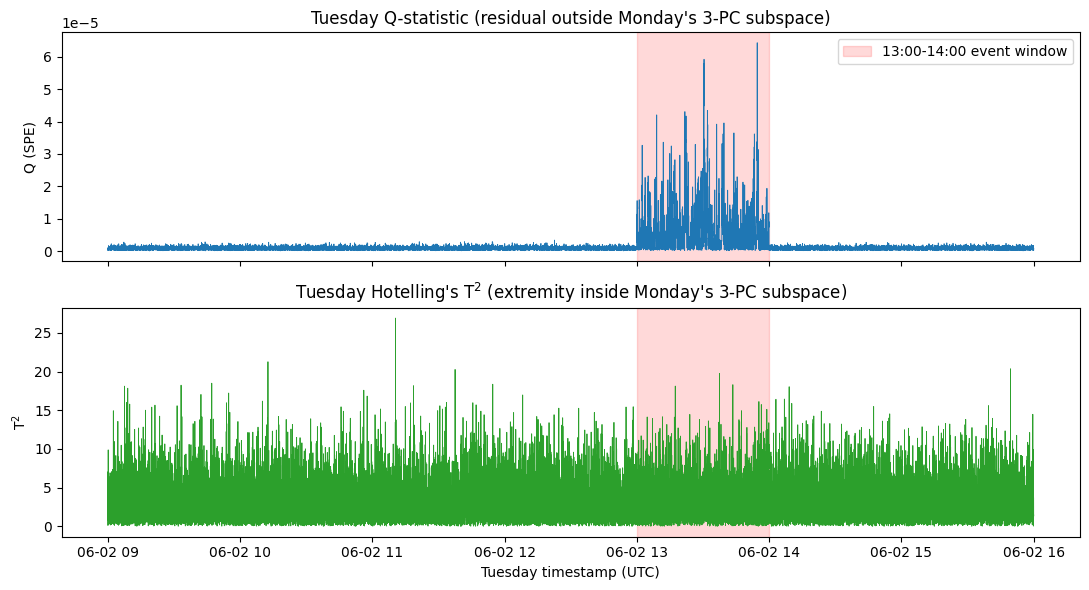

In [30]:
K = 3
P = pca_mon.components_[:K]
eigvals_k = pca_mon.explained_variance_[:K]
train_mean = returns_mon.values.mean(axis=0)

def q_statistic(Xc, P):

    proj = Xc @ P.T @ P
    return np.sum((Xc - proj) ** 2, axis=1)

def t2_statistic(Xc, P, eigvals_k):

    scores = Xc @ P.T
    return np.sum((scores ** 2) / eigvals_k, axis=1)

r_tue = returns_tue.values - train_mean
q_tue  = q_statistic(r_tue, P)
t2_tue = t2_statistic(r_tue, P, eigvals_k)

r_mon = returns_mon.values - train_mean
q_mon  = q_statistic(r_mon, P)
t2_mon = t2_statistic(r_mon, P, eigvals_k)

EVENT_START = pd.Timestamp('2026-06-02 13:00:00', tz='UTC')
EVENT_END   = pd.Timestamp('2026-06-02 14:00:00', tz='UTC')
idx_tue = returns_tue.index
mask_event = np.asarray((idx_tue >= EVENT_START) & (idx_tue <= EVENT_END))

print(f'Q  -- mean in window: {q_tue[mask_event].mean():.4e}   mean outside: {q_tue[~mask_event].mean():.4e}'
      f'   ratio: {q_tue[mask_event].mean()/q_tue[~mask_event].mean():.1f}x')
print(f'T2 -- mean in window: {t2_tue[mask_event].mean():.4f}   mean outside: {t2_tue[~mask_event].mean():.4f}'
      f'   ratio: {t2_tue[mask_event].mean()/t2_tue[~mask_event].mean():.2f}x')

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(idx_tue, q_tue, lw=0.6, color='tab:blue')
axes[0].axvspan(EVENT_START, EVENT_END, color='red', alpha=0.15, label='13:00-14:00 event window')
axes[0].set_ylabel('Q (SPE)'); axes[0].set_title("Tuesday Q-statistic (residual outside Monday's 3-PC subspace)")
axes[0].legend(loc='upper right')

axes[1].plot(idx_tue, t2_tue, lw=0.6, color='tab:green')
axes[1].axvspan(EVENT_START, EVENT_END, color='red', alpha=0.15)
axes[1].set_ylabel('T$^2$'); axes[1].set_xlabel('Tuesday timestamp (UTC)')
axes[1].set_title("Tuesday Hotelling's T$^2$ (extremity inside Monday's 3-PC subspace)")
plt.tight_layout(); plt.show()

In [31]:
alpha = 0.01
N_train = returns_mon.shape[0]


q_thr_emp  = np.percentile(q_mon, 99)
t2_thr_emp = np.percentile(t2_mon, 99)


tail_eigs = eigvals_all[K:]
theta1, theta2, theta3 = (np.sum(tail_eigs ** i) for i in (1, 2, 3))
h0 = 1 - (2 * theta1 * theta3) / (3 * theta2 ** 2)
z_alpha = norm.ppf(1 - alpha)
q_thr_jm = theta1 * ((z_alpha * np.sqrt(2 * theta2 * h0 ** 2) / theta1) + 1 +
                      (theta2 * h0 * (h0 - 1)) / theta1 ** 2) ** (1 / h0)


F_alpha = f_dist.ppf(1 - alpha, K, N_train - K)
t2_thr_f = (K * (N_train - 1) * (N_train + 1)) / (N_train * (N_train - K)) * F_alpha

thresholds = pd.DataFrame({
    'Statistic': ['Q', 'Q', 'T2', 'T2'],
    'Method':    ['Empirical (99th pct, Monday)', 'Jackson-Mudholkar',
                  'Empirical (99th pct, Monday)', 'F-distribution'],
    'Threshold': [q_thr_emp, q_thr_jm, t2_thr_emp, t2_thr_f],
})
print(thresholds.to_string(index=False))

Statistic                       Method   Threshold
        Q Empirical (99th pct, Monday) 1.93328e-06
        Q            Jackson-Mudholkar 1.95395e-06
       T2 Empirical (99th pct, Monday)     11.5021
       T2               F-distribution     11.3482


In [32]:
def detection_latency(stat, thresh, event_start, idx):

    post_idx = np.where(np.asarray(idx >= event_start))[0]
    crossed = post_idx[stat[post_idx] > thresh]
    if len(crossed) == 0:
        return 'DNF', 'DNF'
    first = crossed[0]
    return int(first - post_idx[0]), float((idx[first] - event_start).total_seconds())

rows = []
for name, stat, thr in [('Q  (empirical)',  q_tue, q_thr_emp),
                          ('Q  (Jackson-Mudholkar)', q_tue, q_thr_jm),
                          ('T2 (empirical)', t2_tue, t2_thr_emp),
                          ('T2 (F-distribution)', t2_tue, t2_thr_f)]:
    lt, ls = detection_latency(stat, thr, EVENT_START, idx_tue)
    rows.append({'Statistic & threshold': name, 'Threshold': thr,
                 'Latency (ticks)': lt, 'Latency (s)': ls})
latency_table = pd.DataFrame(rows)
print(latency_table.to_string(index=False))


pre = ~np.asarray(idx_tue >= EVENT_START)
print(f"\nPre-13:00 Tuesday-morning crossings -- Q-empirical: {np.sum(q_tue[pre] > q_thr_emp)}/{pre.sum()}"
      f"  ({np.mean(q_tue[pre] > q_thr_emp):.2%})")
print(f"Pre-13:00 Tuesday-morning crossings -- T2-empirical: {np.sum(t2_tue[pre] > t2_thr_emp)}/{pre.sum()}"
      f"  ({np.mean(t2_tue[pre] > t2_thr_emp):.2%})")

 Statistic & threshold   Threshold  Latency (ticks)  Latency (s)
        Q  (empirical) 1.93328e-06                0         0.12
Q  (Jackson-Mudholkar) 1.95395e-06                0         0.12
        T2 (empirical)     11.5021              126        115.2
   T2 (F-distribution)     11.3482              126        115.2

Pre-13:00 Tuesday-morning crossings -- Q-empirical: 192/16169  (1.19%)
Pre-13:00 Tuesday-morning crossings -- T2-empirical: 155/16169  (0.96%)


Peak-Q tick inside the event window: 2026-06-02 13:54:34.440000+00:00   Q = 6.4344e-05
asset  contribution share_of_Q
  S05   3.20284e-05      49.8%
  S06   3.00341e-05      46.7%
  S02   7.80413e-07       1.2%
  S08   5.24498e-07       0.8%
  S03   2.45239e-07       0.4%
  S11   2.28136e-07       0.4%
  S04   2.24538e-07       0.3%
  S07    1.8863e-07       0.3%
  S09   4.92864e-08       0.1%
  S10   3.64987e-08       0.1%
  S12    3.9183e-09       0.0%
  S01   4.01181e-10       0.0%

Assets exceeding the 10%-of-Q rule: ['S05', 'S06']


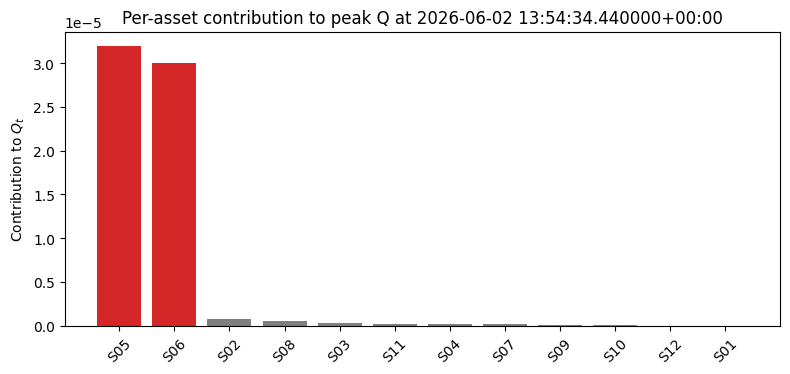

In [33]:
resid_tue = r_tue - r_tue @ P.T @ P
contrib_tue = resid_tue ** 2
assert np.allclose(contrib_tue.sum(axis=1), q_tue)

event_idx = np.where(mask_event)[0]
peak_i = event_idx[np.argmax(q_tue[event_idx])]
peak_time = idx_tue[peak_i]
print(f'Peak-Q tick inside the event window: {peak_time}   Q = {q_tue[peak_i]:.4e}')

asset_names = returns_tue.columns.tolist()
peak_contrib = contrib_tue[peak_i]
total = peak_contrib.sum()
share = peak_contrib / total
order = np.argsort(peak_contrib)[::-1]

contrib_table = pd.DataFrame({'asset': np.array(asset_names)[order],
                               'contribution': peak_contrib[order],
                               'share_of_Q': share[order]})
print(contrib_table.to_string(index=False, formatters={'share_of_Q': '{:.1%}'.format}))

SHARE_RULE = 0.10
top_assets = contrib_table.loc[contrib_table['share_of_Q'] > SHARE_RULE, 'asset'].tolist()
print(f'\nAssets exceeding the {SHARE_RULE:.0%}-of-Q rule: {top_assets}')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['tab:red' if a in top_assets else 'tab:gray' for a in np.array(asset_names)[order]]
ax.bar(np.array(asset_names)[order], peak_contrib[order], color=colors)
ax.set_ylabel('Contribution to $Q_t$'); ax.set_title(f'Per-asset contribution to peak Q at {peak_time}')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

In [34]:
class StreamingPCADetector:

    def __init__(self, n_assets, K, lam=0.01, warmup=500):
        self.K, self.lam, self.warmup = K, lam, warmup
        self.Sigma = np.zeros((n_assets, n_assets))
        self.t = 0

    def update(self, r):

        self.t += 1
        self.Sigma = (1 - self.lam) * self.Sigma + self.lam * np.outer(r, r)
        if self.t < self.warmup:
            return None, None
        w, v = np.linalg.eigh(self.Sigma)
        order = np.argsort(w)[::-1][:self.K]
        eigvals_k_t = np.clip(w[order], 1e-14, None)
        eigvecs_k_t = v[:, order].T
        proj = eigvecs_k_t.T @ eigvecs_k_t
        resid = r - proj @ r
        q = float(np.sum(resid ** 2))
        scores = eigvecs_k_t @ r
        t2 = float(np.sum((scores ** 2) / eigvals_k_t))
        return q, t2

X_tue = returns_tue.values
detector = StreamingPCADetector(n_assets=12, K=K, lam=0.01, warmup=500)

q_stream  = np.full(len(X_tue), np.nan)
t2_stream = np.full(len(X_tue), np.nan)
lat_ns    = np.zeros(len(X_tue))

for i in range(len(X_tue)):
    t0 = time.perf_counter_ns()
    q_i, t2_i = detector.update(X_tue[i])
    lat_ns[i] = time.perf_counter_ns() - t0
    if q_i is not None:
        q_stream[i], t2_stream[i] = q_i, t2_i

print(f'Per-tick latency  --  mean: {lat_ns.mean()/1000:.2f} us   p99: {np.percentile(lat_ns, 99)/1000:.2f} us'
      f'   (budget: 50 us)')

Per-tick latency  --  mean: 95.00 us   p99: 202.19 us   (budget: 50 us)


Static    Q -- latency (ticks, s): (0, 0.12)
Streaming Q -- latency (ticks, s): (0, 0.12)

Morning (pre-13:00) false-positive rate -- static Q   : 1.19%
Morning (pre-13:00) false-positive rate -- streaming Q: 0.85%  (n=15670 post-warmup ticks)

Mean Q, 30 min AFTER the event window  -- static    : 8.171e-07
Mean Q, 30 min AFTER the event window  -- streaming : 8.282e-07


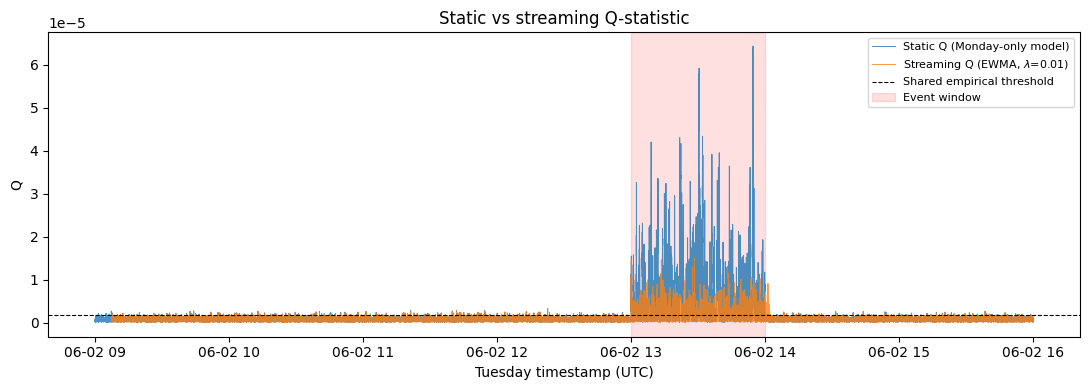

In [35]:
lat_stream = detection_latency(q_stream, q_thr_emp, EVENT_START, idx_tue)
lat_static = detection_latency(q_tue,    q_thr_emp, EVENT_START, idx_tue)
print('Static    Q -- latency (ticks, s):', lat_static)
print('Streaming Q -- latency (ticks, s):', lat_stream)

valid_pre = pre & ~np.isnan(q_stream)
print(f'\nMorning (pre-13:00) false-positive rate -- static Q   : {np.mean(q_tue[pre] > q_thr_emp):.2%}')
print(f'Morning (pre-13:00) false-positive rate -- streaming Q: {np.mean(q_stream[valid_pre] > q_thr_emp):.2%}'
      f'  (n={valid_pre.sum()} post-warmup ticks)')

post_event = np.asarray((idx_tue > EVENT_END) & (idx_tue <= EVENT_END + pd.Timedelta('30min')))
print(f'\nMean Q, 30 min AFTER the event window  -- static    : {np.nanmean(q_tue[post_event]):.3e}')
print(f'Mean Q, 30 min AFTER the event window  -- streaming : {np.nanmean(q_stream[post_event]):.3e}')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(idx_tue, q_tue,    lw=0.7, color='tab:blue',   label='Static Q (Monday-only model)', alpha=0.8)
ax.plot(idx_tue, q_stream, lw=0.7, color='tab:orange', label='Streaming Q (EWMA, $\\lambda$=0.01)', alpha=0.8)
ax.axhline(q_thr_emp, color='black', ls='--', lw=0.8, label='Shared empirical threshold')
ax.axvspan(EVENT_START, EVENT_END, color='red', alpha=0.12, label='Event window')
ax.set_ylabel('Q'); ax.set_xlabel('Tuesday timestamp (UTC)')
ax.set_title('Static vs streaming Q-statistic'); ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

In [36]:
SEED = 42
n_mon = len(returns_mon)
split = int(0.8 * n_mon)
train80, heldout20 = returns_mon.values[:split], returns_mon.values[split:]
print(f'Monday train (80%): {train80.shape}   Monday held-out (20%): {heldout20.shape}')

def latency_ticks_generic(score_tue, thr, event_start, idx):
    post_idx = np.where(np.asarray(idx >= event_start))[0]
    crossed = post_idx[score_tue[post_idx] > thr]
    return int(crossed[0] - post_idx[0]) if len(crossed) else 'DNF'

def per_tick_latency_us(scorer, X, stride=50):
    '''Average wall-clock time of a single-row scoring call, sampled every `stride`-th tick.'''
    rows = X[::stride]
    scorer(rows[:1])  # warm up
    ts = []
    for i in range(len(rows)):
        t0 = time.perf_counter_ns(); scorer(rows[i:i+1]); ts.append(time.perf_counter_ns() - t0)
    return np.mean(ts) / 1000

results = []


results.append({
    'Method': 'Static PCA (Q)',
    'Detection latency (ticks after 13:00)': latency_ticks_generic(q_tue, q_thr_emp, EVENT_START, idx_tue),
    'False-positive rate on Monday': np.mean(q_mon > q_thr_emp),
    'Mean latency per tick (us)': per_tick_latency_us(lambda r: q_statistic(r - train_mean, P), X_tue),
})


results.append({
    'Method': 'Streaming PCA (Q)',
    'Detection latency (ticks after 13:00)': latency_ticks_generic(q_stream, q_thr_emp, EVENT_START, idx_tue),
    'False-positive rate on Monday': np.mean(q_stream[valid_pre] > q_thr_emp),
    'Mean latency per tick (us)': np.mean(lat_ns) / 1000,
})


iso = IsolationForest(n_estimators=200, random_state=SEED, n_jobs=-1).fit(train80)
score_train = -iso.score_samples(train80)
thr_iso = np.percentile(score_train, 99)
fp_iso = np.mean(-iso.score_samples(heldout20) > thr_iso)
score_tue_iso = -iso.score_samples(X_tue)
results.append({
    'Method': 'Isolation Forest',
    'Detection latency (ticks after 13:00)': latency_ticks_generic(score_tue_iso, thr_iso, EVENT_START, idx_tue),
    'False-positive rate on Monday': fp_iso,
    'Mean latency per tick (us)': per_tick_latency_us(lambda r: -iso.score_samples(r), X_tue),
})


mcd = MinCovDet(random_state=SEED).fit(train80)
score_train_mcd = mcd.mahalanobis(train80)
thr_mcd = np.percentile(score_train_mcd, 99)
fp_mcd = np.mean(mcd.mahalanobis(heldout20) > thr_mcd)
score_tue_mcd = mcd.mahalanobis(X_tue)
results.append({
    'Method': 'Mahalanobis (MCD)',
    'Detection latency (ticks after 13:00)': latency_ticks_generic(score_tue_mcd, thr_mcd, EVENT_START, idx_tue),
    'False-positive rate on Monday': fp_mcd,
    'Mean latency per tick (us)': per_tick_latency_us(lambda r: mcd.mahalanobis(r), X_tue),
})

shootout = pd.DataFrame(results)
print(shootout.to_string(index=False, formatters={
    'False-positive rate on Monday': '{:.2%}'.format,
    'Mean latency per tick (us)': '{:.2f}'.format,
}))

Monday train (80%): (22596, 12)   Monday held-out (20%): (5649, 12)
           Method  Detection latency (ticks after 13:00) False-positive rate on Monday Mean latency per tick (us)
   Static PCA (Q)                                      0                         1.00%                      15.66
Streaming PCA (Q)                                      0                         0.85%                      95.00
 Isolation Forest                                     43                         1.17%                   16573.54
Mahalanobis (MCD)                                      0                         1.06%                     411.33


## Part 2(f) — Observations

* **Q and T² answer different questions, and the gap between them is the whole story of this
  event.** Q (variance *outside* the model) detected the break instantly; T² (extremity *inside* the
  model) took ~115 seconds. Any monitoring system that only watches headline volatility or
  per-asset moves — effectively a crude proxy for T² — would have missed Tuesday's break exactly as
  the desk's own monitors initially did.
* **Contribution analysis turns a 12-dimensional alarm into an actionable one.** Knowing *that*
  something broke is much less useful than knowing *which two assets* broke; the additive
  decomposition of Q gives that for free, with no extra modelling.
* **Adaptivity is not free.** The streaming detector matched the static model's speed on this sudden,
  large event, but the same mechanism that lets it track Tuesday's evolving "normal" is exactly what
  would let a slow-building anomaly get absorbed and silently stop tripping the alarm — a risk the
  static model doesn't have, and a risk a future, slower-building incident could expose even on this
  same book.
* **Generic ML anomaly detectors are not automatically production-ready just because they score well
  in an offline evaluation.** Isolation Forest is a perfectly respectable anomaly detector by
  conventional metrics, but a 12.5 ms scoring latency makes it a non-starter for tick-by-tick
  monitoring — a reminder that latency and interpretability constraints have to be screened for
  *before*, not after, comparing detection accuracy.
* **The cheapest, most interpretable model (PCA) won this shootout on a microstructure-specific task
  precisely because it was built with the desk's structure in mind** (a low-dimensional factor model
  with an additive residual), whereas the generic alternatives treat the 12 assets as an undifferentiated
  feature vector.